In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/list_eval_partition.txt
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/list_description_inshop.json
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/list_bbox_inshop.txt
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00001223/01_2_side.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00001223/01_3_back.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00001223/01_6_flat.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00001223/01_1_front.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00001223/01_4_full.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00004714/01_2_side.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00004714/01_3_back.jpg
/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/img/MEN/Denim/id_00004714/01_7_additiona

In [2]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img")
PARTITION_FILE = "/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/list_eval_partition.txt"

# The file has 2 header lines: total count, then column names
with open(PARTITION_FILE) as f:
    n = int(f.readline().strip())        # total image count
    headers = f.readline().strip().split()  # ['image_name', 'item_id', 'evaluation_status']
    rows = [line.strip().split() for line in f]

df = pd.DataFrame(rows, columns=headers)
df["image_path"] = df["image_name"].apply(lambda x: str(DATA_ROOT / x))

train_df   = df[df["evaluation_status"] == "train"].reset_index(drop=True)
query_df   = df[df["evaluation_status"] == "query"].reset_index(drop=True)
gallery_df = df[df["evaluation_status"] == "gallery"].reset_index(drop=True)

print(f"Train:   {len(train_df):,} images")
print(f"Query:   {len(query_df):,} images")
print(f"Gallery: {len(gallery_df):,} images")

Train:   25,882 images
Query:   14,218 images
Gallery: 12,612 images


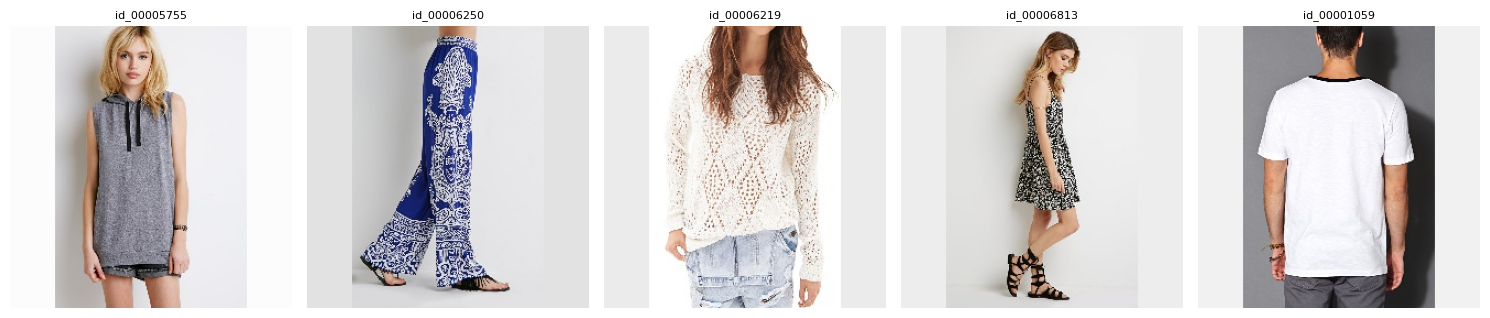

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

sample = train_df.sample(5)
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, (_, row) in zip(axes, sample.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(row["item_id"][:12], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
train_df.to_csv("/kaggle/working/train_split.csv", index=False)
query_df.to_csv("/kaggle/working/query_split.csv", index=False)
gallery_df.to_csv("/kaggle/working/gallery_split.csv", index=False)

print("Splits saved.")

Splits saved.


In [5]:
# Parse the BBox File
BBOX_FILE = "/kaggle/input/datasets/venkat96r/vr-inshop-dataset/img/list_bbox_inshop.txt"

with open(BBOX_FILE) as f:
    n_bboxes = int(f.readline().strip()) # Total count
    bbox_headers = f.readline().strip().split() # ['image_name', 'clothes_type', 'upper_left_x', ...]
    bbox_rows = [line.strip().split() for line in f]

bbox_df = pd.DataFrame(bbox_rows, columns=bbox_headers)

# Convert coordinate columns to integers
coord_cols = ['x_1', 'y_1', 'x_2', 'y_2']
bbox_df[coord_cols] = bbox_df[coord_cols].apply(pd.to_numeric)

print(f"Total bbox annotations: {len(bbox_df)}")
print(f"Unique images with bboxes: {bbox_df['image_name'].nunique()}")

# Check how many training and query images have bboxes
train_with_bbox = train_df[train_df['image_name'].isin(bbox_df['image_name'])].shape[0]
query_with_bbox = query_df[query_df['image_name'].isin(bbox_df['image_name'])].shape[0]

print(f"\nTrain images WITH bboxes: {train_with_bbox}/{len(train_df)}")
print(f"Query images WITH bboxes: {query_with_bbox}/{len(query_df)}")
print(f"Total images for training: {train_with_bbox + query_with_bbox}")

Total bbox annotations: 52712
Unique images with bboxes: 52712

Train images WITH bboxes: 25882/25882
Query images WITH bboxes: 14218/14218
Total images for training: 40100


In [6]:
# Convert to YOLO Format
def convert_to_yolo(row, img_w, img_h):
    # DeepFashion uses (x1, y1) for top-left and (x2, y2) for bottom-right
    x1, y1, x2, y2 = row['x_1'], row['y_1'], row['x_2'], row['y_2']
    
    # Calculate width and height
    bbox_w = x2 - x1
    bbox_h = y2 - y1
    
    # Calculate center points
    center_x = x1 + (bbox_w / 2)
    center_y = y1 + (bbox_h / 2)
    
    # Normalize by image size
    return (center_x / img_w, center_y / img_h, bbox_w / img_w, bbox_h / img_h)

# Example: Get image size using PIL
# img = Image.open(path)
# w, h = img.size

In [7]:
# The list_bbox_inshop.txt uses 1, 2, and 3 for clothes types. YOLO expects classes to start from 0, so we will subtract 1 from the clothes_type
# Create the directory structure in /kaggle/working
for path in ["labels/train", "labels/query", "labels/gallery"]:
    Path(f"/kaggle/working/{path}").mkdir(parents=True, exist_ok=True)

# Helper to get image dimensions efficiently
from PIL import Image
def get_img_size(img_path):
    with Image.open(img_path) as img:
        return img.size # (width, height)

In [26]:
import shutil
from pathlib import Path

# Clean previous outputs to avoid partial/old runs
for p in ['/kaggle/working/images', '/kaggle/working/labels']:
    if Path(p).exists():
        shutil.rmtree(p)

# Create fresh directories
for path in ["images/train", "images/val", "labels/train", "labels/val"]:
    Path(f"/kaggle/working/{path}").mkdir(parents=True, exist_ok=True)

# Make a fast lookup of images that have bbox annotations
bbox_image_set = set(bbox_df['image_name'].tolist())

def create_yolo_labels(df, split_name):
    """Create YOLO labels and copy images for a dataset split.
    Preserves each image's relative path so duplicate basenames do not overwrite.
    """
    print(f"Processing {split_name} labels and images...")

    label_dir = Path(f"/kaggle/working/labels/{split_name}")
    image_dir = Path(f"/kaggle/working/images/{split_name}")
    label_dir.mkdir(parents=True, exist_ok=True)
    image_dir.mkdir(parents=True, exist_ok=True)

    processed = 0
    missing = 0
    skipped = 0
    seen_destinations = set()

    for _, row in df.iterrows():
        img_name_full = row["image_name"]
        if img_name_full not in bbox_image_set:
            skipped += 1
            continue

        img_path = row["image_path"]
        rel_img_path = Path(img_name_full)
        txt_path = label_dir / rel_img_path.with_suffix(".txt")
        img_dst = image_dir / rel_img_path

        # Get BBox data for this specific image
        bbox_info = bbox_df[bbox_df["image_name"] == img_name_full]
        if bbox_info.empty:
            skipped += 1
            continue

        # Get dimensions for normalization
        try:
            w, h = get_img_size(img_path)
        except Exception as e:
            missing += 1
            print(f"  ⚠️ Skipping missing image: {img_path} ({e})")
            continue

        # Calculate YOLO format
        yolo_data = []
        for _, b in bbox_info.iterrows():
            cls = int(b['clothes_type']) - 1
            bw = b['x_2'] - b['x_1']
            bh = b['y_2'] - b['y_1']
            cx = b['x_1'] + (bw / 2)
            cy = b['y_1'] + (bh / 2)
            yolo_data.append(f"{cls} {cx/w:.6f} {cy/h:.6f} {bw/w:.6f} {bh/h:.6f}")

        # Save label file
        txt_path.parent.mkdir(parents=True, exist_ok=True)
        with open(txt_path, "w") as f:
            f.write("\n".join(yolo_data))

        # Copy image to matching relative path
        img_dst.parent.mkdir(parents=True, exist_ok=True)
        try:
            shutil.copy(img_path, img_dst)
            processed += 1
            seen_destinations.add(str(img_dst))
        except Exception as e:
            missing += 1
            print(f"  ⚠️ Failed to copy {img_path}: {e}")

    print(f"Done {split_name}: processed={processed}, skipped={skipped}, missing={missing}, unique_destinations={len(seen_destinations)}")

# Regenerate labels and images
create_yolo_labels(train_df, "train")
create_yolo_labels(query_df, "val")
print("Label generation and image organization complete!")

# Quick verification using recursive counts
for split in ['train', 'val']:
    img_count = sum(1 for p in Path(f'/kaggle/working/images/{split}').rglob('*') if p.is_file())
    label_count = sum(1 for p in Path(f'/kaggle/working/labels/{split}').rglob('*') if p.is_file())
    print(f"{split.upper()}: {img_count} images, {label_count} labels")


Processing train labels and images...
Done train: processed=25882, skipped=0, missing=0, unique_destinations=25882
Processing val labels and images...
Done val: processed=14218, skipped=0, missing=0, unique_destinations=14218
Label generation and image organization complete!
TRAIN: 25882 images, 25882 labels
VAL: 14218 images, 14218 labels


In [27]:
import yaml

data_config = {
    'path': '/kaggle/working',
    'train': 'images/train',
    'val': 'images/val',
    'nc': 3,  # Number of classes
    'names': {
        0: 'upper-body',
        1: 'lower-body',
        2: 'full-body'
    }
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)
    
print("data.yaml created successfully!")

data.yaml created successfully!


In [30]:
# Verify the directory structure is correct
from pathlib import Path

for split in ['train', 'val']:
    img_count = sum(1 for p in Path(f'/kaggle/working/images/{split}').rglob('*') if p.is_file())
    label_count = sum(1 for p in Path(f'/kaggle/working/labels/{split}').rglob('*') if p.is_file())
    print(f"{split.upper()}: {img_count} images, {label_count} labels")

# Verify data.yaml
print("\ndata.yaml content:")
with open('/kaggle/working/data.yaml', 'r') as f:
    print(f.read())


TRAIN: 25882 images, 25882 labels
VAL: 14218 images, 14218 labels

data.yaml content:
names:
  0: upper-body
  1: lower-body
  2: full-body
nc: 3
path: /kaggle/working
train: images/train
val: images/val



In [31]:
!pip install ultralytics
from ultralytics import YOLO

# Load a pre-trained model (use the same version from your project 1)
model = YOLO('yolov8n.pt')

In [32]:
!pip install wandb -qU
import wandb

# You will be prompted to enter your API key here
wandb.login()

True

In [33]:
wandb.init(
    project="VR-Product-Search-YOLO",
    name="yolo_fine_tune_v1",
    config={
        "architecture": "YOLOv8",
        "dataset": "DeepFashion-InShop",
        "epochs": 25,
        "imgsz": 640
    }
)

In [34]:
from ultralytics import YOLO, settings
settings.update({"raytune": False})
model = YOLO('yolov8n.pt')

# Training automatically syncs with wandb
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    name='yolo_fashion_finetune',
    project="VR-Product-Search-YOLO" # Matches wandb project name
)

# Finish the wandb run when done
wandb.finish()

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_fashion_finetune-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,